In [1]:
import os, re, io, json, math, random, zipfile, warnings, subprocess, shutil, gc
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont, ImageFilter
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from fontTools.ttLib import TTFont
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE='cuda' if torch.cuda.is_available() else 'cpu'
print('DEVICE:',DEVICE)
if torch.cuda.is_available(): print(torch.cuda.get_device_name(0))


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

DEVICE: cuda
Tesla T4


In [23]:

!pip uninstall -y transformers tokenizers -q

!pip install -q \
    "transformers==4.46.3" \
    "tokenizers==0.20.3" \
    "sentencepiece==0.2.0" \
    "protobuf<6" \
    "accelerate>=0.26.0" \
    jiwer \
    fonttools

ERROR: Operation cancelled by user


Exception ignored in: <function tqdm.__del__ at 0x7bf05c6442c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/tqdm/std.py", line 1147, in __del__
    def __del__(self):
KeyboardInterrupt: 


KeyboardInterrupt: 

In [2]:
import transformers
import tokenizers
import sentencepiece

print("transformers:", transformers.__version__)
print("tokenizers:", tokenizers.__version__)
print("sentencepiece:", sentencepiece.__version__)

transformers: 4.46.3
tokenizers: 0.20.3
sentencepiece: 0.2.0


In [3]:
MODEL_NAME = "microsoft/trocr-base-handwritten"

print("MODEL_NAME:", MODEL_NAME)

MODEL_NAME: microsoft/trocr-base-handwritten


In [4]:
from transformers import (
    TrOCRProcessor,
    VisionEncoderDecoderModel
)

print("MODEL_NAME:", MODEL_NAME)

processor = TrOCRProcessor.from_pretrained(
    MODEL_NAME
)

print("Processor loaded")

MODEL_NAME: microsoft/trocr-base-handwritten


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Processor loaded


In [5]:

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR=Path('/content/drive/MyDrive/HKR_project')
ANN_PATH=PROJECT_DIR/'ann.zip'
DRIVE_IMG_ZIP=PROJECT_DIR/'img.zip'
OUTPUT_DIR=PROJECT_DIR/'results_pretrained'
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)

# Один раз копируем большой ZIP на локальный SSD Colab — это намного быстрее Drive I/O.
LOCAL_IMG_ZIP=Path('/content/img.zip')
if not LOCAL_IMG_ZIP.exists():
    print('Копирую img.zip с Drive на локальный SSD...')
    shutil.copy2(DRIVE_IMG_ZIP,LOCAL_IMG_ZIP)
IMAGE_SOURCE=LOCAL_IMG_ZIP

PILOT=True #@param {type:'boolean'}
TRAIN_SIZES=[100] if PILOT else [50,100,500,1000]
SYNTHETIC_SIZE=500 if PILOT else 5000
VAL_LIMIT=200 if PILOT else None
TEST_LIMIT=500 if PILOT else None
EPOCHS=5 if PILOT else 10
BATCH_SIZE=4
GRAD_ACCUM=2
LEARNING_RATE=5e-5
MODEL_NAME='microsoft/trocr-small-handwritten'
MAX_LABEL_LENGTH=128

print('ANN:',ANN_PATH,ANN_PATH.exists())
print('LOCAL IMG:',IMAGE_SOURCE,IMAGE_SOURCE.exists())
print('MODEL:',MODEL_NAME)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ANN: /content/drive/MyDrive/HKR_project/ann.zip True
LOCAL IMG: /content/img.zip True
MODEL: microsoft/trocr-small-handwritten


In [6]:

def normalize_text(s):
    s=str(s).replace("\u00a0"," ").strip()
    return re.sub(r"\s+"," ",s)

def load_annotations(zip_path):
    rows=[]; errors=0
    with zipfile.ZipFile(zip_path) as z:
        names=[n for n in z.namelist()
               if n.lower().endswith(".json")
               and "__MACOSX" not in n
               and not Path(n).name.startswith("._")]
        print("Настоящих JSON:",len(names))
        for n in tqdm(names):
            try:
                obj=json.loads(z.read(n).decode("utf-8"))
                name=str(obj.get("name","")).strip()
                text=normalize_text(obj.get("description",""))
                if not name or not text: continue
                if not Path(name).suffix: name += ".jpg"
                rows.append({"image_name":Path(name).name,
                             "text":text,
                             "json_member":n})
            except Exception:
                errors+=1
    df=pd.DataFrame(rows).drop_duplicates(["image_name","text"]).reset_index(drop=True)
    print("Аннотаций:",len(df),"| ошибок:",errors)
    return df

annotations_df=load_annotations(ANN_PATH)
display(annotations_df.head())
assert len(annotations_df)>0

Настоящих JSON: 140355


  0%|          | 0/140355 [00:00<?, ?it/s]

Аннотаций: 140355 | ошибок: 0


,image_name,text,json_member
0,746_005_006.jpg,болсақ,ann/746_005_006.json
1,380_015_002.jpg,арттыру,ann/380_015_002.json
2,1812_002_002.jpg,Осында,ann/1812_002_002.json
3,1649_007_008.jpg,бет,ann/1649_007_008.json
4,1560_013_001.jpg,тұрақты,ann/1560_013_001.json


In [7]:
#@title 4. Индекс изображений и matching
class ImageLocator:
    def __init__(self,source):
        self.source=Path(source); self.index={}; self.stem_index={}; self._zip=None
        with zipfile.ZipFile(self.source) as z:
            for member in z.namelist():
                base=Path(member).name
                if (not base or '__MACOSX' in member or base.startswith('._') or
                    Path(base).suffix.lower() not in {'.jpg','.jpeg','.png','.bmp','.tif','.tiff'}):
                    continue
                self.index[base]=member; self.stem_index[Path(base).stem]=member
        print('Настоящих изображений:',len(self.index))
    def resolve(self,name):
        base=Path(str(name)).name
        return self.index.get(base) or self.stem_index.get(Path(base).stem)
    def _get_zip(self):
        if self._zip is None: self._zip=zipfile.ZipFile(self.source)
        return self._zip
    def open(self,key):
        data=self._get_zip().read(key)
        return Image.open(io.BytesIO(data)).convert('RGB')

locator=ImageLocator(IMAGE_SOURCE)
annotations_df['image_key']=annotations_df.image_name.map(locator.resolve)
annotations_df['image_found']=annotations_df.image_key.notna()
print('Всего:',len(annotations_df))
print('Совпало:',int(annotations_df.image_found.sum()))
print('Не совпало:',int((~annotations_df.image_found).sum()))
matched_df=annotations_df[annotations_df.image_found].copy().reset_index(drop=True)
print('Покрытие:',f'{len(matched_df)/len(annotations_df):.2%}')
assert len(matched_df)>0


Настоящих изображений: 140355
Всего: 140355
Совпало: 115366
Не совпало: 24989
Покрытие: 82.20%


In [ ]:

n=min(6,len(matched_df))
fig,axes=plt.subplots(n,1,figsize=(14,2.4*n))
if n==1: axes=[axes]
for ax,(_,r) in zip(axes,matched_df.sample(n,random_state=SEED).iterrows()):
    ax.imshow(locator.open(r.image_key),cmap="gray")
    ax.set_title(r.text)
    ax.axis("off")
plt.tight_layout(); plt.show()


In [8]:
#@title 6. Очистка и фиксированный REAL split
matched_df['text']=matched_df.text.map(normalize_text)
matched_df=matched_df[matched_df.text.str.len().between(1,120)].copy().reset_index(drop=True)
chars=sorted(set(''.join(matched_df.text.tolist())))
char2idx={c:i+1 for i,c in enumerate(chars)}

train_full,temp=train_test_split(matched_df,test_size=.20,random_state=SEED)
val_df,test_df=train_test_split(temp,test_size=.50,random_state=SEED)
train_full=train_full.reset_index(drop=True); val_df=val_df.reset_index(drop=True); test_df=test_df.reset_index(drop=True)
if VAL_LIMIT is not None: val_df=val_df.sample(n=min(VAL_LIMIT,len(val_df)),random_state=SEED).reset_index(drop=True)
if TEST_LIMIT is not None: test_df=test_df.sample(n=min(TEST_LIMIT,len(test_df)),random_state=SEED+1).reset_index(drop=True)
print('train pool:',len(train_full),'val:',len(val_df),'test:',len(test_df))
print('ПРИМЕЧАНИЕ: это PILOT random split.')


train pool: 92292 val: 200 test: 500
ПРИМЕЧАНИЕ: это PILOT random split.


In [9]:
#@title 7. Вспомогательная функция для старого preview синтетики
IMG_H,IMG_W=64,512
def resize_pad(img,height=IMG_H,width=IMG_W):
    img=img.convert('L'); w,h=img.size
    scale=min(width/max(w,1),height/max(h,1))
    nw,nh=max(1,int(w*scale)),max(1,int(h*scale))
    img=img.resize((nw,nh),Image.Resampling.LANCZOS)
    canvas=Image.new('L',(width,height),255); canvas.paste(img,(0,(height-nh)//2))
    arr=np.asarray(canvas,dtype=np.float32)/255.0
    arr=1.0-arr
    return torch.tensor(arr,dtype=torch.float32).unsqueeze(0)


In [10]:
#@title 8. Поиск Linux-шрифтов с проверкой глифов

# Добавим распространённые Noto-шрифты.
!apt-get -qq update
!apt-get -qq install -y fonts-noto fonts-noto-extra fonts-dejavu-core

def find_fonts():
    roots=[Path("/usr/share/fonts"),Path("/usr/local/share/fonts")]
    out=[]
    for root in roots:
        if root.exists():
            out += list(root.rglob("*.ttf")) + list(root.rglob("*.otf"))
    return sorted(set(out))

def coverage(font_path):
    try:
        f=TTFont(str(font_path),lazy=True)
        s=set()
        for table in f["cmap"].tables:
            s.update(chr(cp) for cp in table.cmap)
        f.close()
        return s
    except Exception:
        return set()

fonts=find_fonts()
font_coverage={str(f):coverage(f) for f in tqdm(fonts)}
font_coverage={f:c for f,c in font_coverage.items() if c}
print("Шрифтов:",len(font_coverage))

def compatible_fonts(text):
    req=set(text)
    return [f for f,cov in font_coverage.items() if req.issubset(cov)]

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


  0%|          | 0/2401 [00:00<?, ?it/s]

Шрифтов: 2401


In [11]:
#@title 9. базовая FONT SYNTHETIC генерация

def synthetic_text_pool(df):
    texts=[normalize_text(t) for t in df.text if normalize_text(t)]
    words=[]
    for t in texts:
        words += [w for w in t.split() if len(w)>=2]
    return texts,words

def make_synthetic_image(text,font_path):
    fs=random.randint(28,48)
    font=ImageFont.truetype(font_path,fs)
    tmp=Image.new("L",(10,10),255)
    d=ImageDraw.Draw(tmp)
    box=d.textbbox((0,0),text,font=font)
    tw,th=max(1,box[2]-box[0]),max(1,box[3]-box[1])
    canvas=Image.new("L",(tw+40,max(IMG_H,th+24)),255)
    d=ImageDraw.Draw(canvas)
    y=max(2,(canvas.height-th)//2-box[1])
    d.text((20,y),text,fill=0,font=font)

    # Простые baseline-аугментации
    canvas=canvas.rotate(random.uniform(-2,2),expand=True,fillcolor=255)
    if random.random()<.30:
        canvas=canvas.filter(ImageFilter.GaussianBlur(random.uniform(.1,.7)))
    arr=np.asarray(canvas,dtype=np.float32)
    arr += np.random.normal(0,random.uniform(1,5),arr.shape)
    arr=np.clip(arr,0,255).astype(np.uint8)
    return Image.fromarray(arr)

class FontSyntheticDataset(Dataset):
    def __init__(self,real_df,size=1000,seed=42):
        self.texts,self.words=synthetic_text_pool(real_df)
        rng=random.Random(seed)
        self.plan=[]
        attempts=0
        while len(self.plan)<size and attempts<size*100:
            attempts+=1
            if self.words and rng.random()<.65:
                k=rng.choice([1,1,2,3])
                text=" ".join(rng.choice(self.words) for _ in range(k))
            else:
                text=rng.choice(self.texts)
            text="".join(c for c in normalize_text(text) if c in char2idx)
            if not text: continue
            good=compatible_fonts(text)
            if not good: continue
            self.plan.append((text,rng.choice(good)))
        print("Synthetic created:",len(self.plan),"/",size)

    def __len__(self): return len(self.plan)

    def __getitem__(self,i):
        text,font=self.plan[i]
        # воспроизводимые аугментации
        py_state=random.getstate(); np_state=np.random.get_state()
        random.seed(SEED+i); np.random.seed(SEED+i)
        img=make_synthetic_image(text,font)
        random.setstate(py_state); np.random.set_state(np_state)
        x=resize_pad(img)
        y=torch.tensor([char2idx[c] for c in text],dtype=torch.long)
        return x,y,text

Synthetic created: 8 / 8


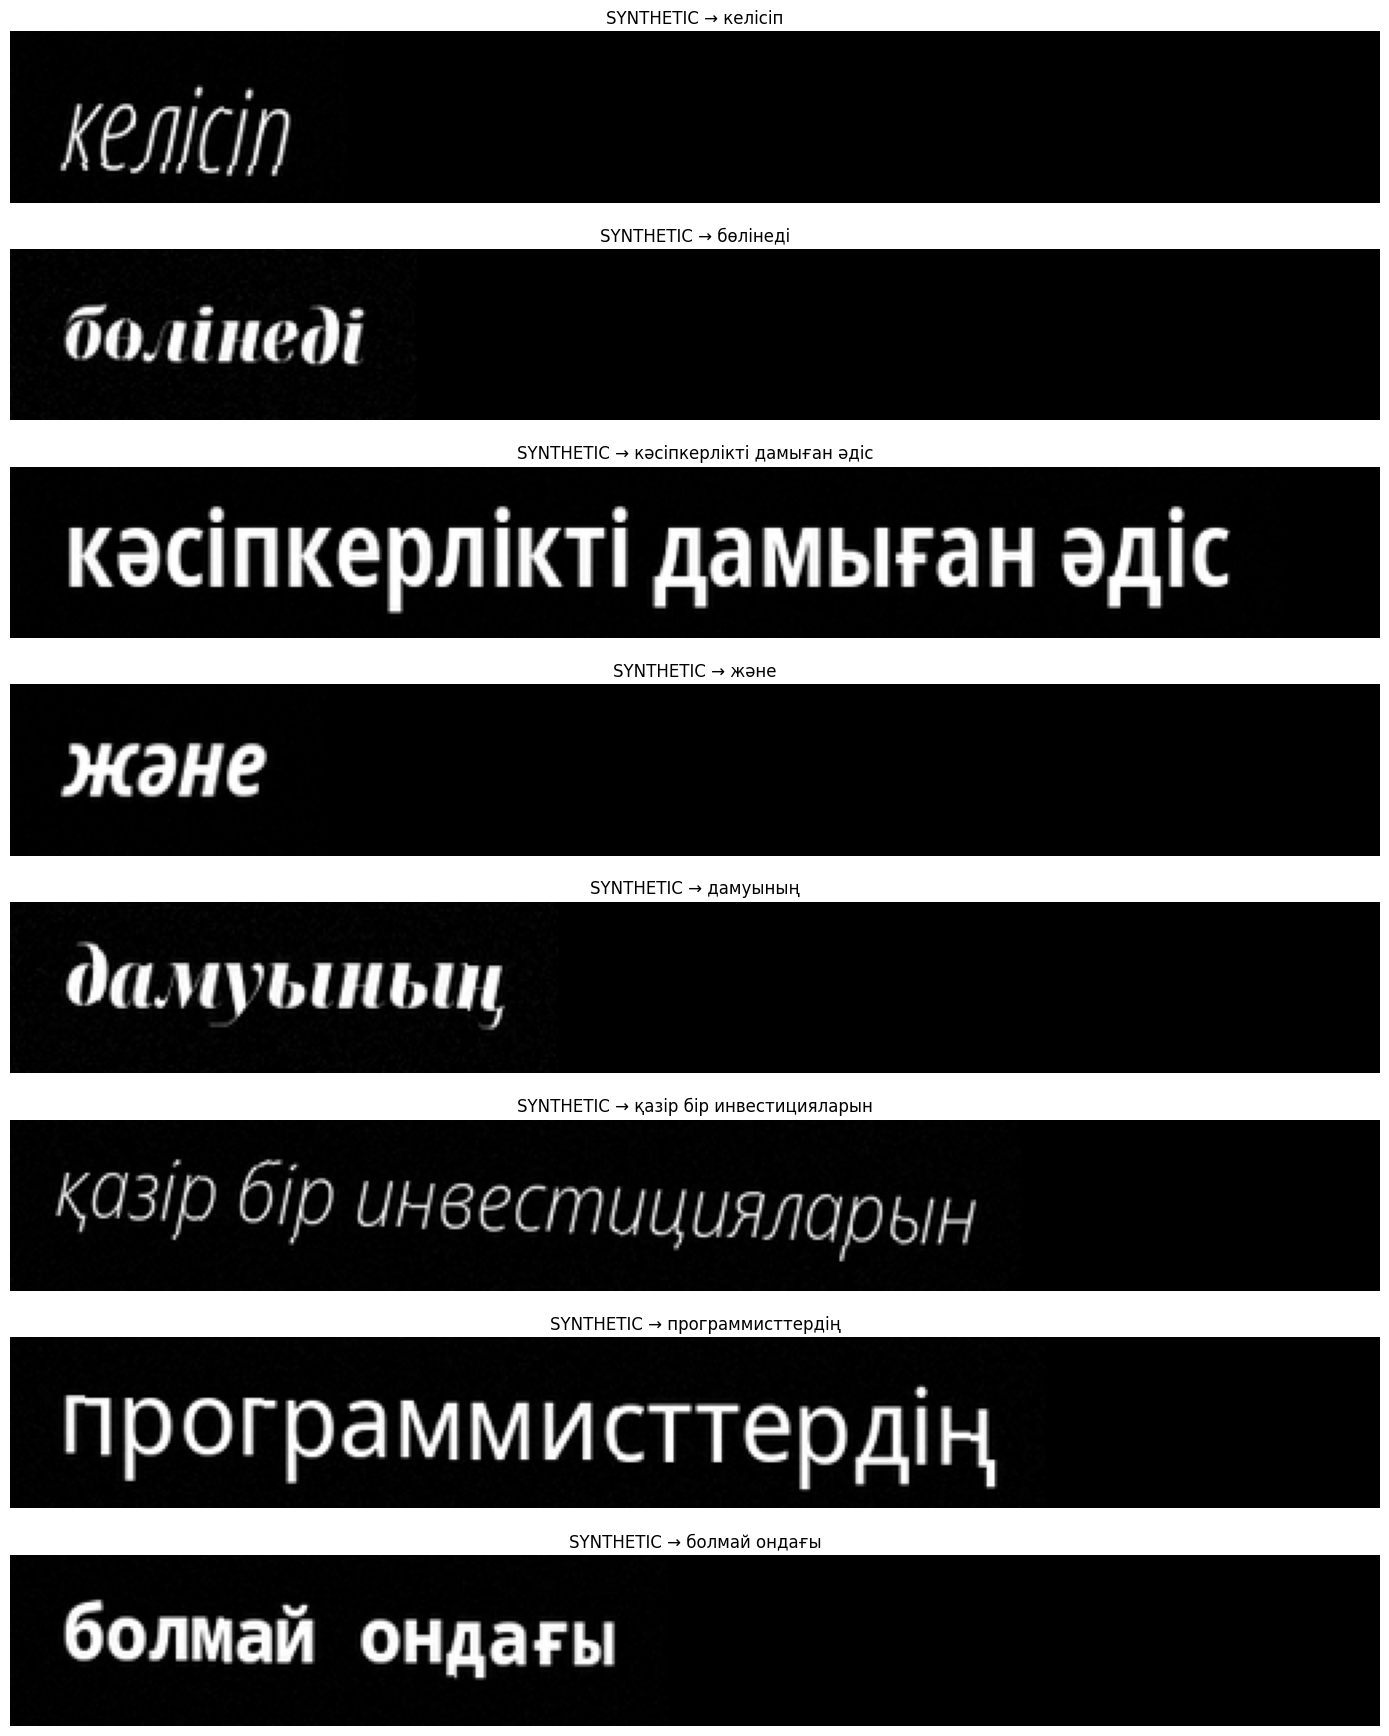

In [12]:
preview=FontSyntheticDataset(train_full,size=8,seed=SEED)
fig,axes=plt.subplots(len(preview),1,figsize=(14,2.2*len(preview)))
if len(preview)==1: axes=[axes]
for i,ax in enumerate(axes):
    x,y,text=preview[i]
    ax.imshow(x.squeeze().numpy(),cmap="gray")
    ax.set_title("SYNTHETIC → "+text)
    ax.axis("off")
plt.tight_layout(); plt.show()

In [13]:
#@title 11. Загрузка TrOCR и проверка кириллицы

from transformers import TrOCRProcessor

processor = TrOCRProcessor.from_pretrained(
    MODEL_NAME,
    use_fast=False
)

print("Processor loaded successfully")

for t in train_full.text.head(10):

    enc = processor.tokenizer(
        t,
        return_tensors="pt",
        add_special_tokens=True
    )

    back = processor.tokenizer.decode(
        enc.input_ids[0],
        skip_special_tokens=True
    )

    print("TRUE:", repr(t))
    print("BACK:", repr(back))
    print("-" * 60)


tokenizer_config.json:   0%|          | 0.00/327 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

Processor loaded successfully
TRUE: 'қатысушылардың'
BACK: 'қатысушылардың'
------------------------------------------------------------
TRUE: 'зейнет'
BACK: 'зейнет'
------------------------------------------------------------
TRUE: 'банк'
BACK: 'банк'
------------------------------------------------------------
TRUE: "' Спутник"
BACK: "' Спутник"
------------------------------------------------------------
TRUE: 'банктер'
BACK: 'банктер'
------------------------------------------------------------
TRUE: 'жататын'
BACK: 'жататын'
------------------------------------------------------------
TRUE: 'мамандарды'
BACK: 'мамандарды'
------------------------------------------------------------
TRUE: 'денсаулы -'
BACK: 'денсаулы -'
------------------------------------------------------------
TRUE: 'мен'
BACK: 'мен'
------------------------------------------------------------
TRUE: 'қадамы'
BACK: 'қадамы'
------------------------------------------------------------


In [14]:
#@title 12. Dataset для TrOCR
class RealTrOCRDataset(Dataset):
    def __init__(self,df): self.df=df.reset_index(drop=True)
    def __len__(self): return len(self.df)
    def __getitem__(self,i):
        r=self.df.iloc[i]
        return locator.open(r.image_key), r.text

class FontTrOCRDataset(Dataset):
    def __init__(self,real_df,size,seed=42):
        # Используем тот же план, что и наш font baseline, но отдаём PIL + text для TrOCR.
        base=FontSyntheticDataset(real_df,size=size,seed=seed)
        self.plan=base.plan
    def __len__(self): return len(self.plan)
    def __getitem__(self,i):
        text,font=self.plan[i]
        py_state=random.getstate(); np_state=np.random.get_state()
        random.seed(SEED+i); np.random.seed(SEED+i)
        img=make_synthetic_image(text,font).convert('RGB')
        random.setstate(py_state); np.random.set_state(np_state)
        return img,text

def trocr_collate(batch):
    images,texts=zip(*batch)
    pixel_values=processor(images=list(images),return_tensors='pt').pixel_values
    tok=processor.tokenizer(list(texts),padding=True,truncation=True,max_length=MAX_LABEL_LENGTH,return_tensors='pt')
    labels=tok.input_ids
    labels[labels==processor.tokenizer.pad_token_id]=-100
    return pixel_values,labels,list(texts)

def make_loader(ds,shuffle=False):
    return DataLoader(ds,batch_size=BATCH_SIZE,shuffle=shuffle,num_workers=0,collate_fn=trocr_collate,pin_memory=torch.cuda.is_available())


In [15]:
#@title 13. CER / WER
def edit_distance(a,b):
    prev=list(range(len(b)+1))
    for i,ca in enumerate(a,1):
        cur=[i]
        for j,cb in enumerate(b,1):
            cur.append(min(cur[-1]+1,prev[j]+1,prev[j-1]+(ca!=cb)))
        prev=cur
    return prev[-1]

def corpus_cer(refs,hyps):
    return sum(edit_distance(list(r),list(h)) for r,h in zip(refs,hyps))/max(1,sum(len(r) for r in refs))

def corpus_wer(refs,hyps):
    return sum(edit_distance(r.split(),h.split()) for r,h in zip(refs,hyps))/max(1,sum(len(r.split()) for r in refs))


In [16]:
#@title 14. Оценка TrOCR
@torch.no_grad()
def evaluate_model(model,ds,show=0):
    model.eval(); refs=[]; hyps=[]
    dl=make_loader(ds,shuffle=False)
    for pixel_values,labels,texts in tqdm(dl,leave=False):
        pixel_values=pixel_values.to(DEVICE)
        generated=model.generate(pixel_values,max_new_tokens=MAX_LABEL_LENGTH,num_beams=1)
        preds=processor.batch_decode(generated,skip_special_tokens=True)
        refs.extend(texts); hyps.extend([normalize_text(x) for x in preds])
    if show:
        for r,h in list(zip(refs,hyps))[:show]: print('TRUE:',repr(r),'\nPRED:',repr(h),'\n')
    return corpus_cer(refs,hyps),corpus_wer(refs,hyps),refs,hyps


In [17]:
#@title 15. Fine-tuning одной исходной pretrained-модели
def fresh_model():
    model=VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)
    model.config.decoder_start_token_id=processor.tokenizer.cls_token_id
    model.config.pad_token_id=processor.tokenizer.pad_token_id
    model.config.eos_token_id=processor.tokenizer.sep_token_id
    model.config.vocab_size=model.config.decoder.vocab_size
    return model.to(DEVICE)

def train_one_regime(train_ds,val_ds,tag):
    model=fresh_model()
    opt=torch.optim.AdamW(model.parameters(),lr=LEARNING_RATE)
    train_dl=make_loader(train_ds,shuffle=True)
    best_cer=float('inf'); best_path=OUTPUT_DIR/f'{tag}_best.pt'

    for epoch in range(1,EPOCHS+1):
        model.train(); opt.zero_grad(set_to_none=True); total=0.0; steps=0
        for step,(pixel_values,labels,_) in enumerate(tqdm(train_dl,desc=f'{tag} ep{epoch}',leave=False),1):
            pixel_values=pixel_values.to(DEVICE); labels=labels.to(DEVICE)
            out=model(pixel_values=pixel_values,labels=labels)
            loss=out.loss/GRAD_ACCUM
            loss.backward(); total+=loss.item()*GRAD_ACCUM; steps+=1
            if step%GRAD_ACCUM==0 or step==len(train_dl):
                torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
                opt.step(); opt.zero_grad(set_to_none=True)
        val_cer,val_wer,_,_=evaluate_model(model,val_ds)
        print(f'{tag} epoch={epoch} loss={total/max(1,steps):.4f} val_CER={val_cer:.4f} val_WER={val_wer:.4f}')
        if val_cer<best_cer:
            best_cer=val_cer
            torch.save(model.state_dict(),best_path)

    model.load_state_dict(torch.load(best_path,map_location=DEVICE))
    return model


In [18]:
#@title 16. Быстрый sanity-check pretrained модели ДО fine-tuning
val_ds=RealTrOCRDataset(val_df)
test_ds=RealTrOCRDataset(test_df)
base_model=fresh_model()
base_cer,base_wer,_,_=evaluate_model(base_model,val_ds,show=5)
print(f'PRETRAINED без fine-tuning: val CER={base_cer:.4f}, WER={base_wer:.4f}')
del base_model
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/246M [00:00<?, ?B/s]

Config of the encoder: <class 'transformers.models.deit.modeling_deit.DeiTModel'> is overwritten by shared encoder config: DeiTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 384,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 1536,
  "layer_norm_eps": 1e-12,
  "model_type": "deit",
  "num_attention_heads": 6,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": true,
  "transformers_version": "4.46.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 384,
  "d_model": 256,
  "decoder_attention_heads": 8,
  "decoder_ffn_dim": 1024,
  "decode

generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  0%|          | 0/50 [00:00<?, ?it/s]

TRUE: 'сол' 
PRED: 'enough' 

TRUE: 'Одан' 
PRED: 'References' 

TRUE: '1) Реттеушілік-' 
PRED: 'self-ofappeachably necessary .' 

TRUE: 'Іскері' 
PRED: 'a b' 

TRUE: 'есептелуі' 
PRED: 'a b c d' 

PRETRAINED без fine-tuning: val CER=2.6205, WER=2.9567


In [19]:
#@title 17. ОСНОВНОЙ ЭКСПЕРИМЕНТ: real_only vs real_plus_font
results=[]; all_predictions=[]

for n_real in TRAIN_SIZES:
    sub=train_full.sample(n=min(n_real,len(train_full)),random_state=SEED+n_real).reset_index(drop=True)
    real_ds=RealTrOCRDataset(sub)
    synth_ds=FontTrOCRDataset(sub,size=SYNTHETIC_SIZE,seed=SEED+n_real)

    regimes={
        'real_only': real_ds,
        'real_plus_font': ConcatDataset([real_ds,synth_ds]),
    }

    for regime,train_ds in regimes.items():
        print('\n'+'='*70)
        print(f'N_REAL={len(sub)} | {regime} | train={len(train_ds)}')
        model=train_one_regime(train_ds,val_ds,f'{regime}_n{len(sub)}')
        cer,wer,refs,hyps=evaluate_model(model,test_ds,show=5)
        print(f'REAL TEST: CER={cer:.4f} WER={wer:.4f}')
        results.append({'n_real':len(sub),'n_synth':0 if regime=='real_only' else len(synth_ds),'regime':regime,'CER':cer,'WER':wer})
        all_predictions.extend({'n_real':len(sub),'regime':regime,'reference':r,'prediction':h} for r,h in zip(refs,hyps))
        pd.DataFrame(results).to_csv(OUTPUT_DIR/'results.csv',index=False)
        pd.DataFrame(all_predictions).to_csv(OUTPUT_DIR/'predictions.csv',index=False)
        del model
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

results_df=pd.DataFrame(results)
display(results_df)


Synthetic created: 500 / 500

N_REAL=100 | real_only | train=100


Config of the encoder: <class 'transformers.models.deit.modeling_deit.DeiTModel'> is overwritten by shared encoder config: DeiTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 384,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 1536,
  "layer_norm_eps": 1e-12,
  "model_type": "deit",
  "num_attention_heads": 6,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": true,
  "transformers_version": "4.46.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 384,
  "d_model": 256,
  "decoder_attention_heads": 8,
  "decoder_ffn_dim": 1024,
  "decode

real_only_n100 ep1:   0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

real_only_n100 epoch=1 loss=10.8068 val_CER=6.0245 val_WER=3.6058


...

  0%|          | 0/50 [00:00<?, ?it/s]

real_plus_font_n100 epoch=5 loss=2.1937 val_CER=0.9755 val_WER=1.3125


  0%|          | 0/125 [00:00<?, ?it/s]

TRUE: 'ипотекалық' 
PRED: 'баеешы' 

TRUE: 'бар' 
PRED: 'быға' 

TRUE: 'аптасына' 
PRED: 'баееешы' 

TRUE: 'жатқызамыз' 
PRED: 'баееешы' 

TRUE: 'өз' 
PRED: 'бы' 

REAL TEST: CER=0.8842 WER=1.0441


,n_real,n_synth,regime,CER,WER
0,100,0,real_only,0.957198,1.000000
1,100,500,real_plus_font,0.884166,1.044146


In [20]:
#@title 18. Эффект синтетики
if len(results_df):
    p=results_df.pivot(index='n_real',columns='regime',values=['CER','WER'])
    display(p)
    rows=[]
    for n in sorted(results_df.n_real.unique()):
        q=results_df[results_df.n_real==n].set_index('regime')
        if {'real_only','real_plus_font'}.issubset(q.index):
            rows.append({
                'n_real':n,
                'CER_real_only':q.loc['real_only','CER'],
                'CER_real_plus_font':q.loc['real_plus_font','CER'],
                'delta_CER':q.loc['real_plus_font','CER']-q.loc['real_only','CER'],
                'relative_CER_change_%':100*(q.loc['real_plus_font','CER']-q.loc['real_only','CER'])/max(q.loc['real_only','CER'],1e-12),
                'WER_real_only':q.loc['real_only','WER'],
                'WER_real_plus_font':q.loc['real_plus_font','WER'],
                'delta_WER':q.loc['real_plus_font','WER']-q.loc['real_only','WER'],
            })
    effect_df=pd.DataFrame(rows)
    display(effect_df)
    effect_df.to_csv(OUTPUT_DIR/'effect_summary.csv',index=False)
    print('delta_CER < 0 означает улучшение после добавления font synthetic.')


CER                      WER               
regime real_only real_plus_font real_only real_plus_font
n_real                                                  
100     0.957198       0.884166       1.0       1.044146

,n_real,CER_real_only,CER_real_plus_font,delta_CER,relative_CER_change_%,WER_real_only,WER_real_plus_font,delta_WER
0,100,0.957198,0.884166,-0.073032,-7.629769,1.0,1.044146,0.044146


delta_CER < 0 означает улучшение после добавления font synthetic.


In [21]:

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR=Path('/content/drive/MyDrive/HKR_project')
ANN_PATH=PROJECT_DIR/'ann.zip'
DRIVE_IMG_ZIP=PROJECT_DIR/'img.zip'
OUTPUT_DIR=PROJECT_DIR/'results_pretrained'
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)

LOCAL_IMG_ZIP=Path('/content/img.zip')
if not LOCAL_IMG_ZIP.exists():
    print('img.zip с Drive на локальный SSD...')
    shutil.copy2(DRIVE_IMG_ZIP,LOCAL_IMG_ZIP)
IMAGE_SOURCE=LOCAL_IMG_ZIP

PILOT=True #@param {type:'boolean'}
TRAIN_SIZES=[500] if PILOT else [50,100,500,1000]
SYNTHETIC_SIZE=500 if PILOT else 5000
VAL_LIMIT=200 if PILOT else None
TEST_LIMIT=500 if PILOT else None
EPOCHS=5 if PILOT else 10
BATCH_SIZE=4
GRAD_ACCUM=2
LEARNING_RATE=5e-5
MODEL_NAME='microsoft/trocr-small-handwritten'
MAX_LABEL_LENGTH=128

print('ANN:',ANN_PATH,ANN_PATH.exists())
print('LOCAL IMG:',IMAGE_SOURCE,IMAGE_SOURCE.exists())
print('MODEL:',MODEL_NAME)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ANN: /content/drive/MyDrive/HKR_project/ann.zip True
LOCAL IMG: /content/img.zip True
MODEL: microsoft/trocr-small-handwritten


In [24]:
#@title 17. ОСНОВНОЙ ЭКСПЕРИМЕНТ: real_only vs real_plus_font (500\500)
results=[]; all_predictions=[]

for n_real in TRAIN_SIZES:
    sub=train_full.sample(n=min(n_real,len(train_full)),random_state=SEED+n_real).reset_index(drop=True)
    real_ds=RealTrOCRDataset(sub)
    synth_ds=FontTrOCRDataset(sub,size=SYNTHETIC_SIZE,seed=SEED+n_real)

    regimes={
        'real_only': real_ds,
        'real_plus_font': ConcatDataset([real_ds,synth_ds]),
    }

    for regime,train_ds in regimes.items():
        print('\n'+'='*70)
        print(f'N_REAL={len(sub)} | {regime} | train={len(train_ds)}')
        model=train_one_regime(train_ds,val_ds,f'{regime}_n{len(sub)}')
        cer,wer,refs,hyps=evaluate_model(model,test_ds,show=5)
        print(f'REAL TEST: CER={cer:.4f} WER={wer:.4f}')
        results.append({'n_real':len(sub),'n_synth':0 if regime=='real_only' else len(synth_ds),'regime':regime,'CER':cer,'WER':wer})
        all_predictions.extend({'n_real':len(sub),'regime':regime,'reference':r,'prediction':h} for r,h in zip(refs,hyps))
        pd.DataFrame(results).to_csv(OUTPUT_DIR/'results.csv',index=False)
        pd.DataFrame(all_predictions).to_csv(OUTPUT_DIR/'predictions.csv',index=False)
        del model
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

results_df=pd.DataFrame(results)
display(results_df)


Synthetic created: 500 / 500

N_REAL=500 | real_only | train=500


Config of the encoder: <class 'transformers.models.deit.modeling_deit.DeiTModel'> is overwritten by shared encoder config: DeiTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 384,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 1536,
  "layer_norm_eps": 1e-12,
  "model_type": "deit",
  "num_attention_heads": 6,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": true,
  "transformers_version": "4.46.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 384,
  "d_model": 256,
  "decoder_attention_heads": 8,
  "decoder_ffn_dim": 1024,
  "decode

real_only_n500 ep1:   0%|          | 0/125 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

real_only_n500 epoch=1 loss=6.6786 val_CER=1.0000 val_WER=1.0000


...

  0%|          | 0/50 [00:00<?, ?it/s]

real_plus_font_n500 epoch=5 loss=2.5616 val_CER=0.8676 val_WER=1.0000


  0%|          | 0/125 [00:00<?, ?it/s]

TRUE: 'ипотекалық' 
PRED: 'жазазы' 

TRUE: 'бар' 
PRED: 'қы' 

TRUE: 'аптасына' 
PRED: 'жазазы' 

TRUE: 'жатқызамыз' 
PRED: 'жазазы' 

TRUE: 'өз' 
PRED: 'же' 

REAL TEST: CER=0.8602 WER=1.0000


,n_real,n_synth,regime,CER,WER
0,500,0,real_only,0.880575,1.0
1,500,500,real_plus_font,0.860221,1.0


In [25]:
#@title 18. Эффект синтетики
if len(results_df):
    p=results_df.pivot(index='n_real',columns='regime',values=['CER','WER'])
    display(p)
    rows=[]
    for n in sorted(results_df.n_real.unique()):
        q=results_df[results_df.n_real==n].set_index('regime')
        if {'real_only','real_plus_font'}.issubset(q.index):
            rows.append({
                'n_real':n,
                'CER_real_only':q.loc['real_only','CER'],
                'CER_real_plus_font':q.loc['real_plus_font','CER'],
                'delta_CER':q.loc['real_plus_font','CER']-q.loc['real_only','CER'],
                'relative_CER_change_%':100*(q.loc['real_plus_font','CER']-q.loc['real_only','CER'])/max(q.loc['real_only','CER'],1e-12),
                'WER_real_only':q.loc['real_only','WER'],
                'WER_real_plus_font':q.loc['real_plus_font','WER'],
                'delta_WER':q.loc['real_plus_font','WER']-q.loc['real_only','WER'],
            })
    effect_df=pd.DataFrame(rows)
    display(effect_df)
    effect_df.to_csv(OUTPUT_DIR/'effect_summary.csv',index=False)
    print('delta_CER < 0 означает улучшение после добавления font synthetic.')


CER                      WER               
regime real_only real_plus_font real_only real_plus_font
n_real                                                  
500     0.880575       0.860221       1.0            1.0

,n_real,CER_real_only,CER_real_plus_font,delta_CER,relative_CER_change_%,WER_real_only,WER_real_plus_font,delta_WER
0,500,0.880575,0.860221,-0.020353,-2.311353,1.0,1.0,0.0


delta_CER < 0 означает улучшение после добавления font synthetic.


In [26]:

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR=Path('/content/drive/MyDrive/HKR_project')
ANN_PATH=PROJECT_DIR/'ann.zip'
DRIVE_IMG_ZIP=PROJECT_DIR/'img.zip'
OUTPUT_DIR=PROJECT_DIR/'results_pretrained'
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)

LOCAL_IMG_ZIP=Path('/content/img.zip')
if not LOCAL_IMG_ZIP.exists():
    print('img.zip с Drive на локальный SSD...')
    shutil.copy2(DRIVE_IMG_ZIP,LOCAL_IMG_ZIP)
IMAGE_SOURCE=LOCAL_IMG_ZIP

PILOT=True #@param {type:'boolean'}
TRAIN_SIZES=[1000] if PILOT else [50,100,500,1000]
SYNTHETIC_SIZE=500 if PILOT else 5000
VAL_LIMIT=200 if PILOT else None
TEST_LIMIT=500 if PILOT else None
EPOCHS=5 if PILOT else 10
BATCH_SIZE=4
GRAD_ACCUM=2
LEARNING_RATE=5e-5
MODEL_NAME='microsoft/trocr-small-handwritten'
MAX_LABEL_LENGTH=128

print('ANN:',ANN_PATH,ANN_PATH.exists())
print('LOCAL IMG:',IMAGE_SOURCE,IMAGE_SOURCE.exists())
print('MODEL:',MODEL_NAME)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ANN: /content/drive/MyDrive/HKR_project/ann.zip True
LOCAL IMG: /content/img.zip True
MODEL: microsoft/trocr-small-handwritten


In [27]:
#@title 17. ОСНОВНОЙ ЭКСПЕРИМЕНТ: real_only vs real_plus_font 1000 real
results=[]; all_predictions=[]

for n_real in TRAIN_SIZES:
    sub=train_full.sample(n=min(n_real,len(train_full)),random_state=SEED+n_real).reset_index(drop=True)
    real_ds=RealTrOCRDataset(sub)
    synth_ds=FontTrOCRDataset(sub,size=SYNTHETIC_SIZE,seed=SEED+n_real)

    regimes={
        'real_only': real_ds,
        'real_plus_font': ConcatDataset([real_ds,synth_ds]),
    }

    for regime,train_ds in regimes.items():
        print('\n'+'='*70)
        print(f'N_REAL={len(sub)} | {regime} | train={len(train_ds)}')
        model=train_one_regime(train_ds,val_ds,f'{regime}_n{len(sub)}')
        cer,wer,refs,hyps=evaluate_model(model,test_ds,show=5)
        print(f'REAL TEST: CER={cer:.4f} WER={wer:.4f}')
        results.append({'n_real':len(sub),'n_synth':0 if regime=='real_only' else len(synth_ds),'regime':regime,'CER':cer,'WER':wer})
        all_predictions.extend({'n_real':len(sub),'regime':regime,'reference':r,'prediction':h} for r,h in zip(refs,hyps))
        pd.DataFrame(results).to_csv(OUTPUT_DIR/'results.csv',index=False)
        pd.DataFrame(all_predictions).to_csv(OUTPUT_DIR/'predictions.csv',index=False)
        del model
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

results_df=pd.DataFrame(results)
display(results_df)


Synthetic created: 500 / 500

N_REAL=1000 | real_only | train=1000


Config of the encoder: <class 'transformers.models.deit.modeling_deit.DeiTModel'> is overwritten by shared encoder config: DeiTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 384,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 1536,
  "layer_norm_eps": 1e-12,
  "model_type": "deit",
  "num_attention_heads": 6,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": true,
  "transformers_version": "4.46.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 384,
  "d_model": 256,
  "decoder_attention_heads": 8,
  "decoder_ffn_dim": 1024,
  "decode

real_only_n1000 ep1:   0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

real_only_n1000 epoch=1 loss=5.2378 val_CER=1.0038 val_WER=1.0000


...

  0%|          | 0/50 [00:00<?, ?it/s]

real_plus_font_n1000 epoch=5 loss=2.2975 val_CER=0.8523 val_WER=1.0000


  0%|          | 0/125 [00:00<?, ?it/s]

TRUE: 'ипотекалық' 
PRED: 'қайызмың' 

TRUE: 'бар' 
PRED: 'елі' 

TRUE: 'аптасына' 
PRED: 'жайылы' 

TRUE: 'жатқызамыз' 
PRED: 'қасықтары' 

TRUE: 'өз' 
PRED: 'е' 

REAL TEST: CER=0.8515 WER=1.0077


,n_real,n_synth,regime,CER,WER
0,1000,0,real_only,0.846752,1.000000
1,1000,500,real_plus_font,0.851541,1.007678


In [28]:
#@title 18. Эффект синтетики
if len(results_df):
    p=results_df.pivot(index='n_real',columns='regime',values=['CER','WER'])
    display(p)
    rows=[]
    for n in sorted(results_df.n_real.unique()):
        q=results_df[results_df.n_real==n].set_index('regime')
        if {'real_only','real_plus_font'}.issubset(q.index):
            rows.append({
                'n_real':n,
                'CER_real_only':q.loc['real_only','CER'],
                'CER_real_plus_font':q.loc['real_plus_font','CER'],
                'delta_CER':q.loc['real_plus_font','CER']-q.loc['real_only','CER'],
                'relative_CER_change_%':100*(q.loc['real_plus_font','CER']-q.loc['real_only','CER'])/max(q.loc['real_only','CER'],1e-12),
                'WER_real_only':q.loc['real_only','WER'],
                'WER_real_plus_font':q.loc['real_plus_font','WER'],
                'delta_WER':q.loc['real_plus_font','WER']-q.loc['real_only','WER'],
            })
    effect_df=pd.DataFrame(rows)
    display(effect_df)
    effect_df.to_csv(OUTPUT_DIR/'effect_summary.csv',index=False)
    print('delta_CER < 0 означает улучшение после добавления font synthetic.')


CER                      WER               
regime real_only real_plus_font real_only real_plus_font
n_real                                                  
1000    0.846752       0.851541       1.0       1.007678

,n_real,CER_real_only,CER_real_plus_font,delta_CER,relative_CER_change_%,WER_real_only,WER_real_plus_font,delta_WER
0,1000,0.846752,0.851541,0.004789,0.565571,1.0,1.007678,0.007678


delta_CER < 0 означает улучшение после добавления font synthetic.
